# 1. Exploratory Data Analysis (EDA)

Notebook ini bertujuan untuk **mengeksplorasi** dataset agro-environmental secara menyeluruh.
Tidak ada perubahan data yang dilakukan di sini — hanya observasi dan visualisasi.

## 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agar visualisasi tampil langsung di notebook
%matplotlib inline

# Style agar grafik lebih rapi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Library berhasil diimport.')

Library berhasil diimport.


## 1.2 Load Dataset

In [2]:
# Muat dataset dari file CSV
df = pd.read_csv('../dataset/agro_environmental_dataset.csv')

print(f'Dataset berhasil dimuat.')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')

Dataset berhasil dimuat.
Jumlah baris   : 543,210
Jumlah kolom   : 25


## 1.3 Info Umum Dataset

In [3]:
# Tampilkan 5 baris pertama
print('=== 5 Baris Pertama ===')
df.head()

=== 5 Baris Pertama ===


,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


In [4]:
# Info tipe data setiap kolom
print('=== Info Tipe Data ===')
df.info()

=== Info Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime       

In [5]:
# Statistik deskriptif untuk kolom numerik
print('=== Statistik Deskriptif (Numerik) ===')
df.describe().round(3)

=== Statistik Deskriptif (Numerik) ===


,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,soil_temp_c,air_temp_c,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,suitability_score,stress_level,failure_flag
count,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.000,543210.00,543210.000,543210.000,543210.000
mean,1.319,4.000,17.212,0.674,0.610,34.977,16.946,42.566,25.004,28.007,699.682,6.499,0.206,100.370,50.593,110.29,0.613,0.915,0.162
std,0.243,4.278,10.367,0.986,0.199,11.928,6.615,9.682,4.991,5.379,288.943,0.892,0.405,39.139,23.828,43.77,0.246,0.743,0.369
min,0.700,1.200,5.000,0.200,0.300,5.000,8.000,28.000,10.000,7.000,200.000,4.000,0.000,20.000,10.000,20.00,0.000,0.000,0.000
25%,1.300,1.800,8.000,0.300,0.400,26.870,12.000,38.000,21.600,24.400,450.000,5.890,0.000,73.000,33.100,79.70,0.457,0.000,0.000
50%,1.300,3.500,15.000,0.400,0.700,34.970,16.000,42.000,25.000,28.000,699.000,6.500,0.000,100.000,50.100,110.00,0.628,1.000,0.000
75%,1.500,3.800,20.000,0.500,0.700,43.070,22.000,45.000,28.400,31.600,949.000,7.110,0.000,127.000,66.900,140.30,0.784,1.000,0.000
max,1.600,18.000,40.000,4.000,0.900,70.000,30.000,65.000,40.000,49.600,1200.000,8.800,1.000,220.000,159.000,220.00,1.000,2.000,1.000


In [6]:
# Statistik untuk kolom kategorikal
print('=== Statistik Deskriptif (Kategorikal) ===')
df.describe(include='object')

=== Statistik Deskriptif (Kategorikal) ===


,location_id,soil_type,moisture_regime,thermal_regime,nutrient_balance,plant_category
count,543210,543210,543210,543210,543210,543210
unique,543210,9,3,3,3,3
top,L00000,Loamy,optimal,optimal,deficient,cereal
freq,1,108778,319135,413078,405882,217332


## 1.4 Cek Missing Value & Duplikat

In [7]:
# Cek jumlah missing value per kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
})

print('=== Missing Value per Kolom ===')
print(missing_df[missing_df['Jumlah Missing'] > 0].to_string() or 'Tidak ada missing value.')

=== Missing Value per Kolom ===
Empty DataFrame
Columns: [Jumlah Missing, Persentase (%)]
Index: []


In [8]:
# Cek jumlah baris duplikat
n_duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_duplicates}')

Jumlah baris duplikat: 0


## 1.5 Distribusi Target (failure_flag)

=== Distribusi failure_flag ===
  Kelas 0: 455,130 (83.8%)
  Kelas 1: 88,080 (16.2%)


/var/folders/ds/v017qf_x1yl6z8bv9k6gjjwr0000gn/T/ipykernel_4958/1523278123.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


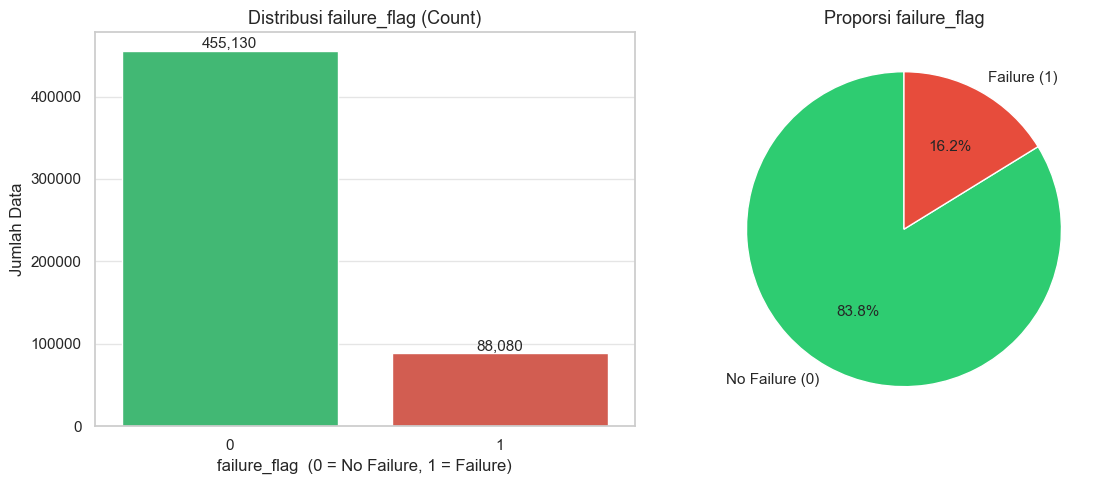

In [9]:
# Hitung jumlah dan persentase tiap kelas target
target_counts = df['failure_flag'].value_counts()
target_pct    = df['failure_flag'].value_counts(normalize=True) * 100

print('=== Distribusi failure_flag ===')
for label in target_counts.index:
    print(f'  Kelas {label}: {target_counts[label]:,} ({target_pct[label]:.1f}%)')

# Visualisasi countplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(
    data=df, x='failure_flag',
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_title('Distribusi failure_flag (Count)', fontsize=13)
axes[0].set_xlabel('failure_flag  (0 = No Failure, 1 = Failure)')
axes[0].set_ylabel('Jumlah Data')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(
    target_counts,
    labels=['No Failure (0)', 'Failure (1)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi failure_flag', fontsize=13)

plt.tight_layout()
plt.show()

## 1.6 Distribusi Fitur Numerik

Kolom numerik yang akan divisualisasi: ['bulk_density', 'organic_matter_pct', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'soil_temp_c', 'air_temp_c', 'light_intensity_par', 'soil_ph', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'suitability_score']


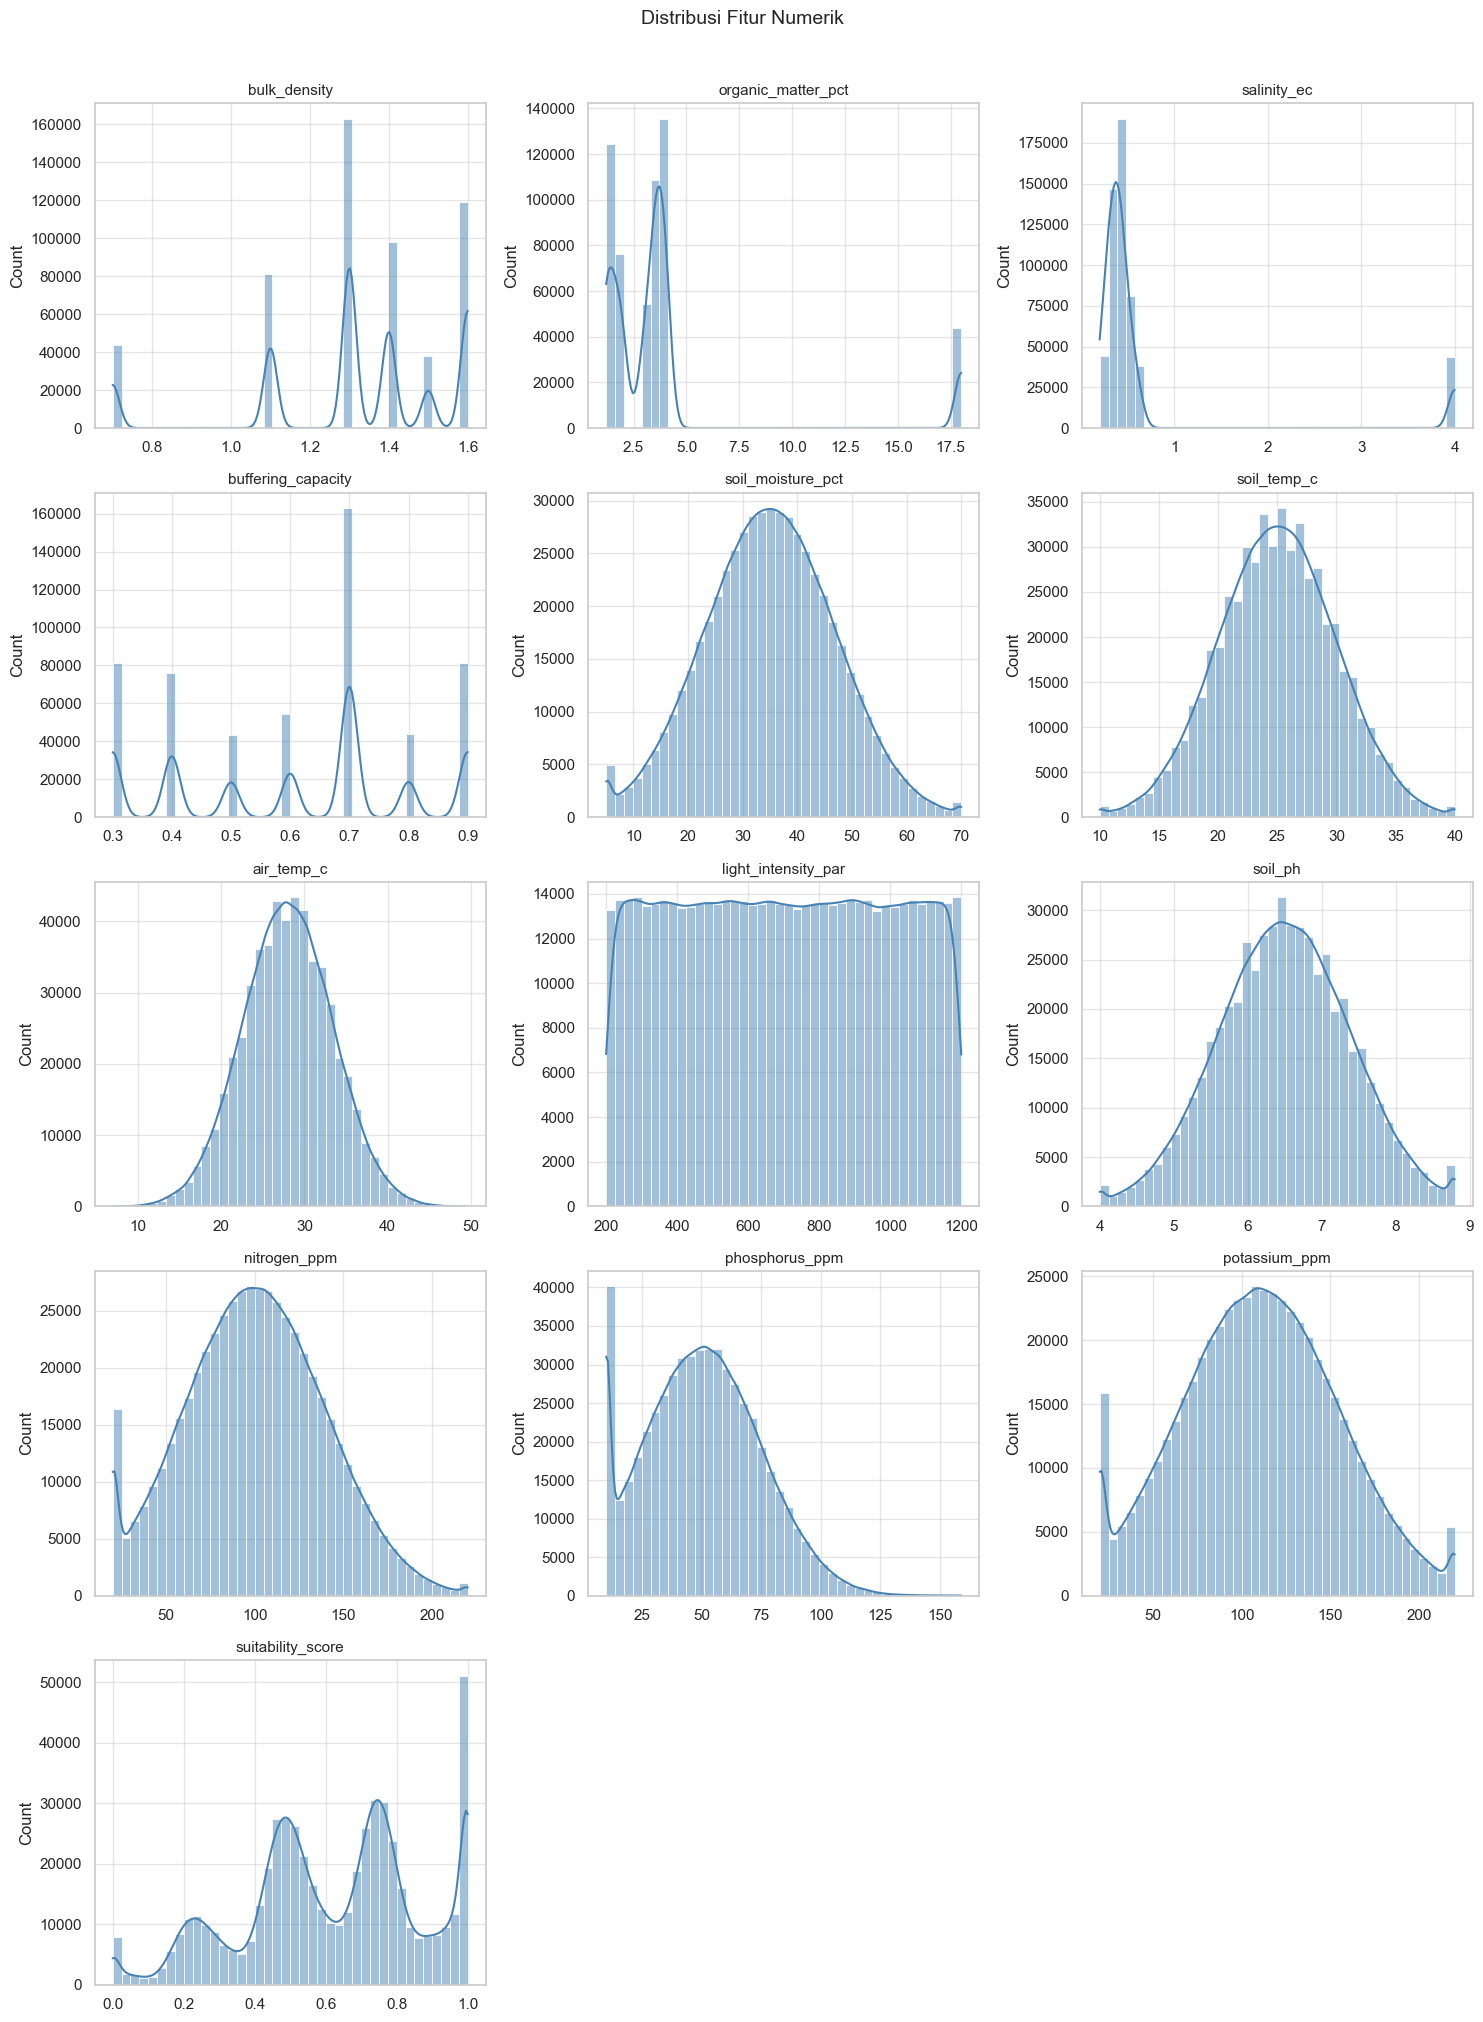

In [10]:
# Pilih kolom numerik (kecuali target dan flag biner)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Keluarkan kolom target dan flag biner sederhana
exclude = ['failure_flag', 'ph_stress_flag', 'stress_level',
           'moisture_limit_dry', 'moisture_limit_wet', 'cation_exchange_capacity']
num_cols_plot = [c for c in num_cols if c not in exclude]

print(f'Kolom numerik yang akan divisualisasi: {num_cols_plot}')

# Histogram untuk setiap kolom numerik
n = len(num_cols_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

# Sembunyikan subplot yang tidak dipakai
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.7 Distribusi Fitur Kategorikal

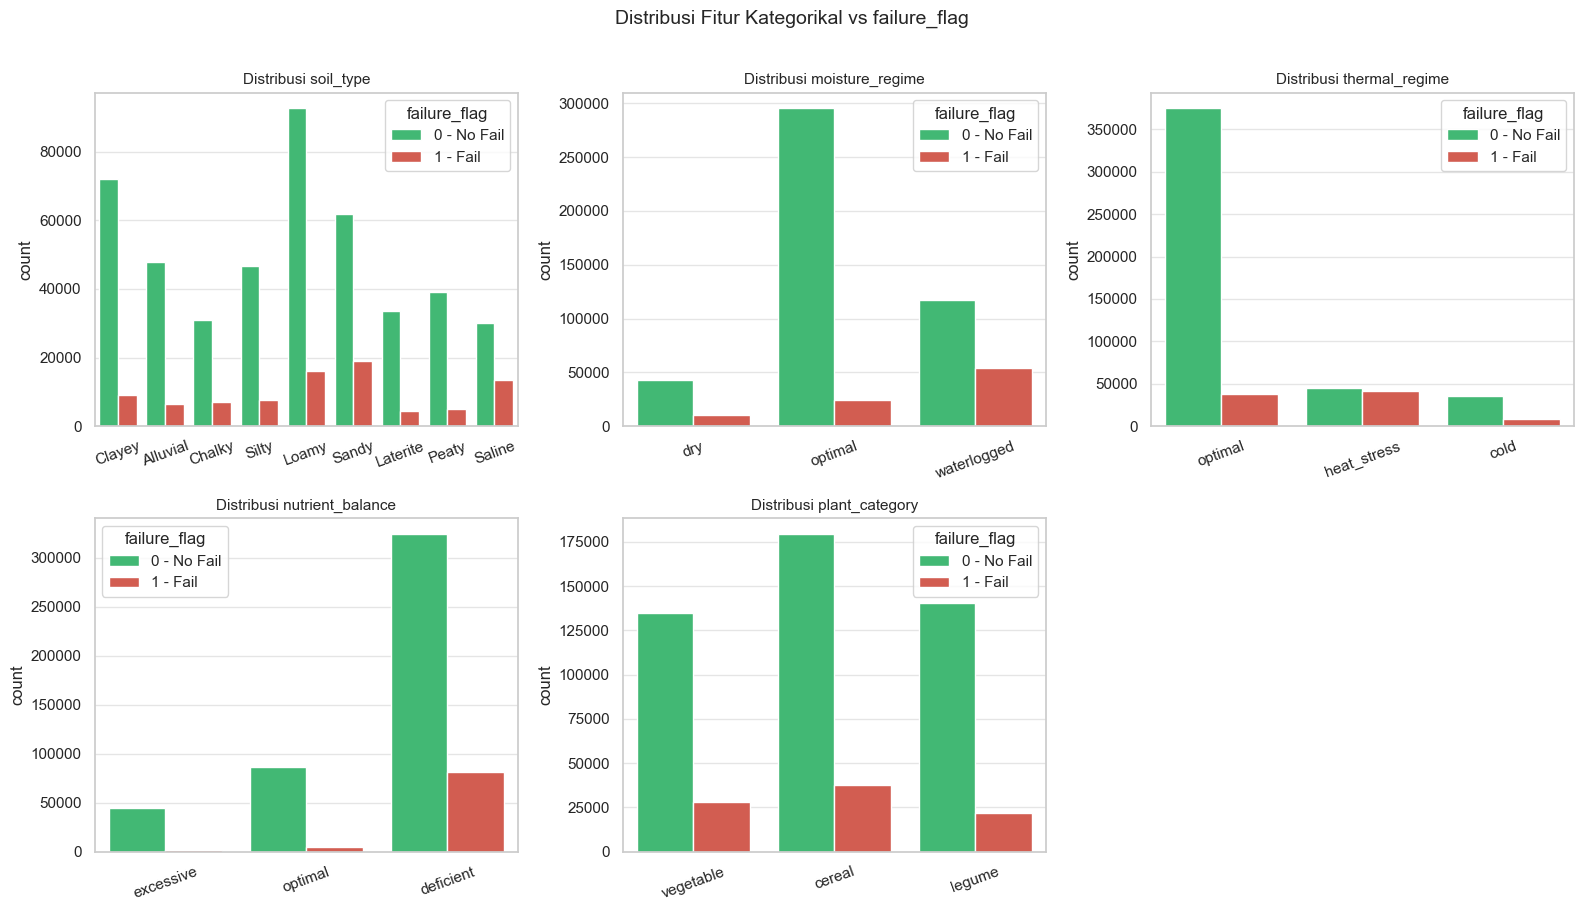

In [11]:
# Kolom kategorikal yang akan diplot (kecuali location_id yang terlalu banyak nilai unik)
cat_cols = ['soil_type', 'moisture_regime', 'thermal_regime',
            'nutrient_balance', 'plant_category']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Hitung per kombinasi (kategori x target)
    sns.countplot(
        data=df, x=col, hue='failure_flag',
        palette={0: '#2ecc71', 1: '#e74c3c'},
        ax=axes[i]
    )
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(title='failure_flag', labels=['0 - No Fail', '1 - Fail'])

# Sembunyikan subplot kosong
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal vs failure_flag', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.8 Korelasi Antar Fitur (Heatmap)

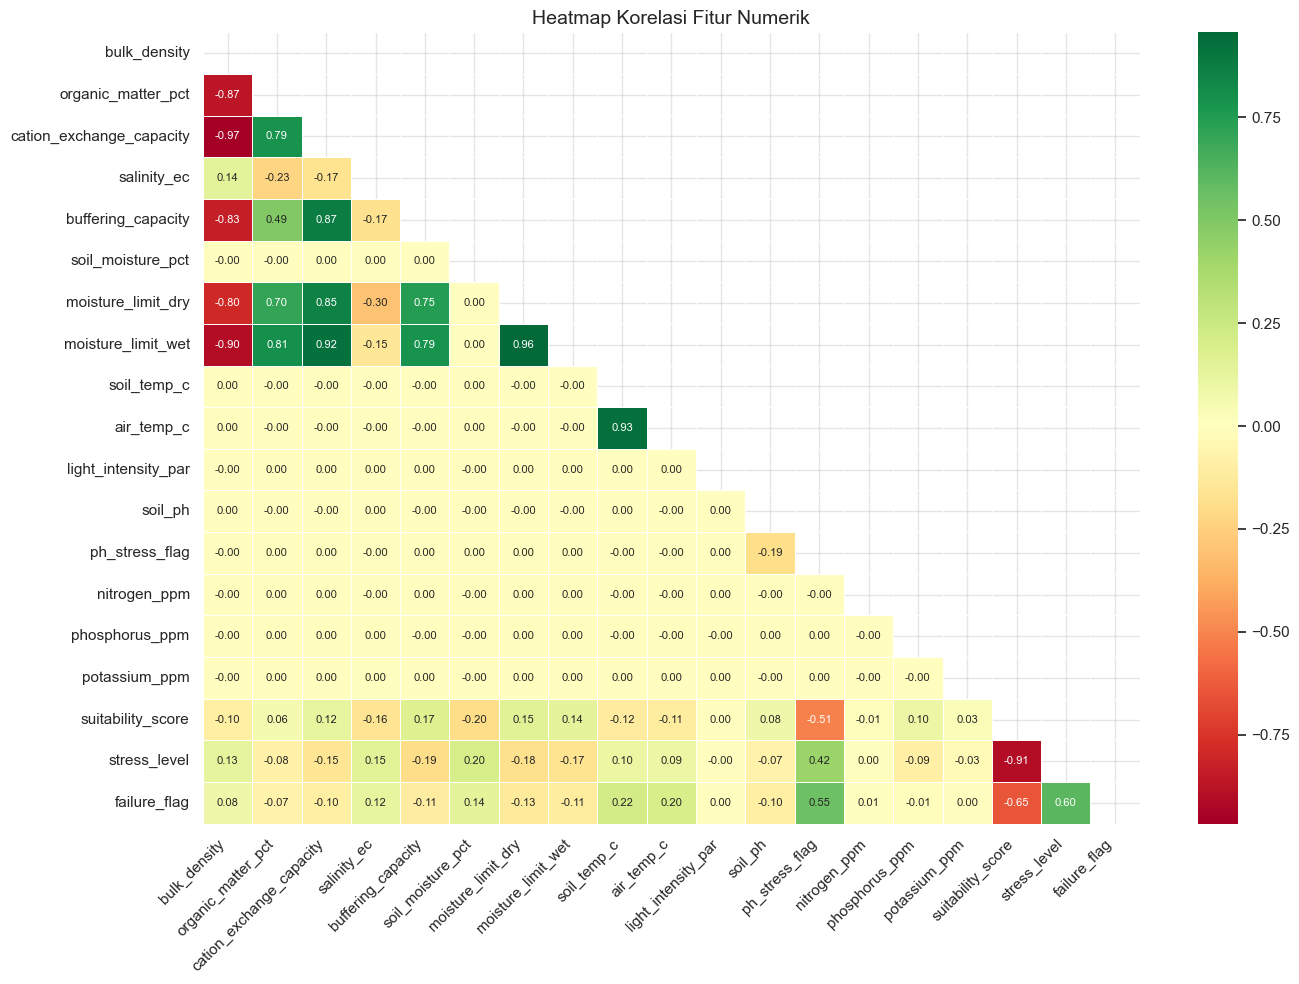

In [12]:
# Hitung matriks korelasi untuk fitur numerik saja
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas agar tidak redundan
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

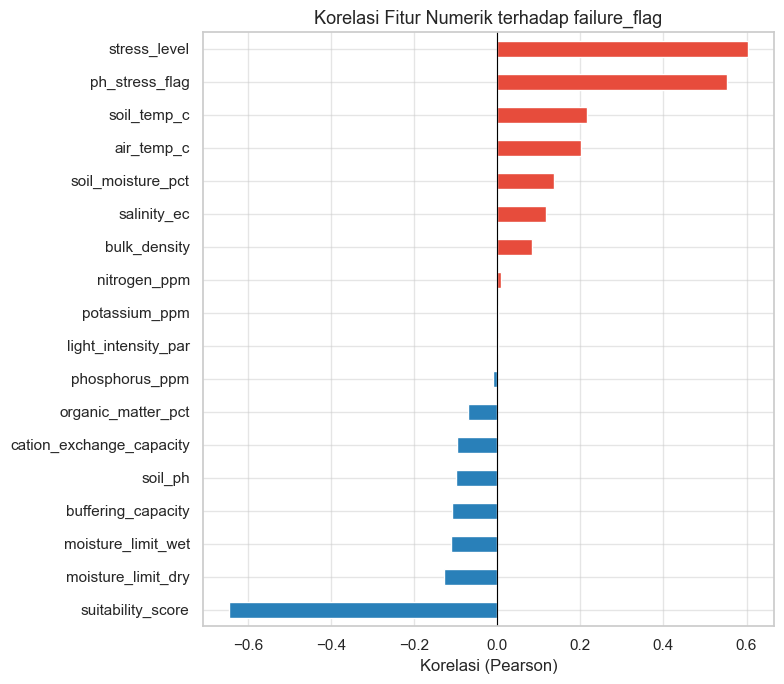

In [13]:
# Korelasi setiap fitur numerik terhadap target
corr_target = df[num_cols].corr()['failure_flag'].drop('failure_flag').sort_values()

plt.figure(figsize=(8, 7))
colors = ['#e74c3c' if v > 0 else '#2980b9' for v in corr_target]
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur Numerik terhadap failure_flag', fontsize=13)
plt.xlabel('Korelasi (Pearson)')
plt.tight_layout()
plt.show()

## 1.9 Boxplot: Distribusi Numerik per Kelas Target

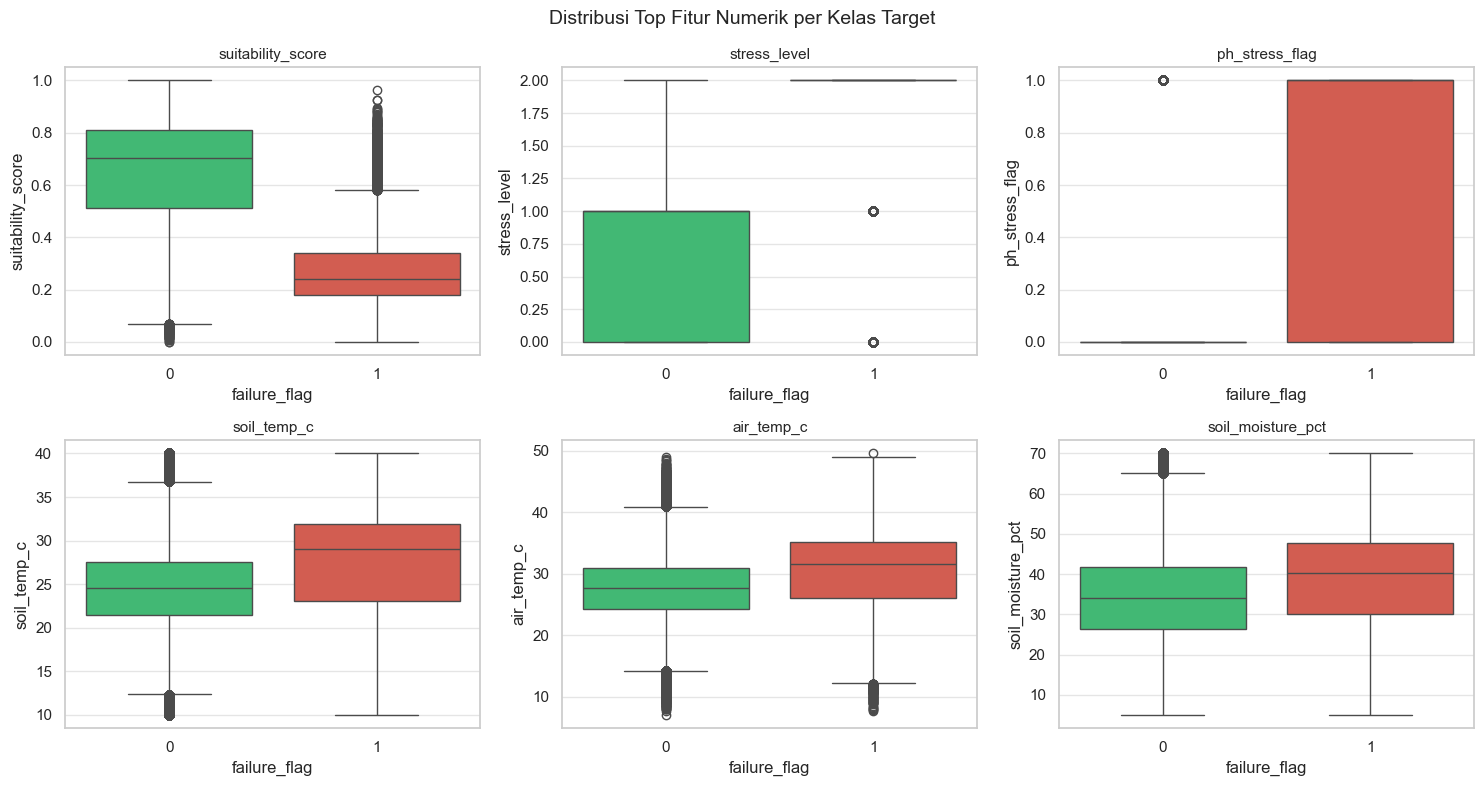

In [16]:
# Pilih beberapa fitur yang berkorelasi kuat dengan target untuk boxplot
top_features = corr_target.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(
    data=df, x='failure_flag', y=col,
    hue='failure_flag',                      # ← tambahkan hue
    palette={0: '#2ecc71', 1: '#e74c3c'},
    legend=False,                            # ← sembunyikan legend otomatis
    ax=axes[i]
)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('failure_flag')

plt.suptitle('Distribusi Top Fitur Numerik per Kelas Target', fontsize=14)
plt.tight_layout()
plt.show()

## 1.10 Insight Singkat dari Data

In [17]:
print('=' * 60)
print('INSIGHT UTAMA DARI EDA')
print('=' * 60)

print(f"""
1. UKURAN DATASET
   - Total {df.shape[0]:,} baris dan {df.shape[1]} kolom.
   - Tidak ditemukan missing value maupun duplikat.

2. KETIDAKSEIMBANGAN KELAS (Class Imbalance)
   - failure_flag = 0 (No Failure): {(df['failure_flag']==0).sum():,} ({(df['failure_flag']==0).mean()*100:.1f}%)
   - failure_flag = 1 (Failure)   : {(df['failure_flag']==1).sum():,} ({(df['failure_flag']==1).mean()*100:.1f}%)
   → Dataset tidak seimbang (~{round((df['failure_flag']==0).mean()*100)}% vs ~{round((df['failure_flag']==1).mean()*100)}%).
     Perlu penanganan saat training (misal: SMOTE).

3. FITUR PALING BERKORELASI DENGAN TARGET
   - Korelasi positif (meningkatkan risiko failure):
     {', '.join(corr_target[corr_target > 0].nlargest(3).index.tolist())}
   - Korelasi negatif (menurunkan risiko failure):
     {', '.join(corr_target[corr_target < 0].nsmallest(3).index.tolist())}

4. DISTRIBUSI FITUR NUMERIK
   - Sebagian besar fitur numerik terdistribusi mendekati normal.
   - Perlu scaling saat training (StandardScaler / MinMaxScaler).

5. FITUR KATEGORIKAL
   - Terdapat 5 kolom kategorikal relevan: soil_type, moisture_regime,
     thermal_regime, nutrient_balance, plant_category.
   - Kolom location_id bersifat ID unik → tidak informatif untuk model.

6. REKOMENDASI UNTUK PREPROCESSING
   - Hapus kolom location_id (ID unik, tidak berguna untuk model).
   - Encoding untuk kolom kategorikal (OneHotEncoder).
   - Scaling untuk fitur numerik.
   - Tangani class imbalance menggunakan SMOTE di pipeline training.
""")

INSIGHT UTAMA DARI EDA

1. UKURAN DATASET
   - Total 543,210 baris dan 25 kolom.
   - Tidak ditemukan missing value maupun duplikat.

2. KETIDAKSEIMBANGAN KELAS (Class Imbalance)
   - failure_flag = 0 (No Failure): 455,130 (83.8%)
   - failure_flag = 1 (Failure)   : 88,080 (16.2%)
   → Dataset tidak seimbang (~84% vs ~16%).
     Perlu penanganan saat training (misal: SMOTE).

3. FITUR PALING BERKORELASI DENGAN TARGET
   - Korelasi positif (meningkatkan risiko failure):
     stress_level, ph_stress_flag, soil_temp_c
   - Korelasi negatif (menurunkan risiko failure):
     suitability_score, moisture_limit_dry, moisture_limit_wet

4. DISTRIBUSI FITUR NUMERIK
   - Sebagian besar fitur numerik terdistribusi mendekati normal.
   - Perlu scaling saat training (StandardScaler / MinMaxScaler).

5. FITUR KATEGORIKAL
   - Terdapat 5 kolom kategorikal relevan: soil_type, moisture_regime,
     thermal_regime, nutrient_balance, plant_category.
   - Kolom location_id bersifat ID unik → tidak informat